# Universe Trend Diagnosis — is the edge eroding, and is it the vol regime?

The 24-name clean portfolio's daily P&L fell ~31% first-half to second-half. This notebook diagnoses **why**, testing two competing explanations:

1. **Vol regime (the 'war' hypothesis):** MM dies in jumpy markets. If the erosion is a regime effect, P&L should fall *broadly across all names together*, timed to *spikes in market-wide volatility*. This is **recoverable** — when vol normalises, the edge returns.
2. **Structural decay:** specific names dying while others hold, *unrelated* to a vol spike. This is **not recoverable** by waiting.

The test: overlay portfolio daily P&L against market-wide realized volatility. If P&L troughs line up with vol peaks → regime. If P&L erodes while vol is flat → decay.

*Note: this can confirm 'erosion tracks a vol regime' or not — it cannot attribute the vol to any specific news event. Overlay your own headline calendar on the dates it flags.* Run All.

In [6]:
# ---- imports + load ----
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
%matplotlib inline
try:
    import duckdb
    HAVE_DUCK = True
except ImportError:
    HAVE_DUCK = False

# the universe daily CSV (edit if your filename/stamp differs; auto-picks newest)
RESULTS = Path('/Users/shazzak/Capital Stake - Results')
FS_ROOT = '/Users/shazzak/Capital Stake - Results/feature_store'
cands = sorted(RESULTS.glob('universe_daily_*.csv'))
assert cands, 'no universe_daily_*.csv found'
d = pd.read_csv(cands[-1]); d['date'] = pd.to_datetime(d['date'])
# ranked file (for the clean-portfolio membership)
rc = sorted(RESULTS.glob('universe_ranked_*.csv'))
r = pd.read_csv(rc[-1])
print(f'loaded {cands[-1].name} and {rc[-1].name}')

# the 24 clean-profitable names: mid_pnl>0 & unclean_liq_days<=3
PORT = sorted(r[(r.mid_pnl>0)&(r.unclean_liq_days<=3)]['symbol'].tolist())
print(f'{len(PORT)} clean-portfolio names: {PORT}')
# MID rows for the portfolio only
mid = d[(d.config=='MID') & (d.symbol.isin(PORT))].copy()

loaded universe_daily_20260819_0206.csv and universe_ranked_20260819_0206.csv
24 clean-portfolio names: ['ATRL', 'BAFL', 'DGKC', 'ENGROH', 'FFC', 'HBL', 'HUBC', 'KEL', 'LUCK', 'MARI', 'MEBL', 'MLCF', 'NBP', 'NML', 'NRL', 'OGDC', 'PAEL', 'PIBTL', 'PPL', 'PSO', 'SAZEW', 'SEARL', 'SYS', 'UBL']


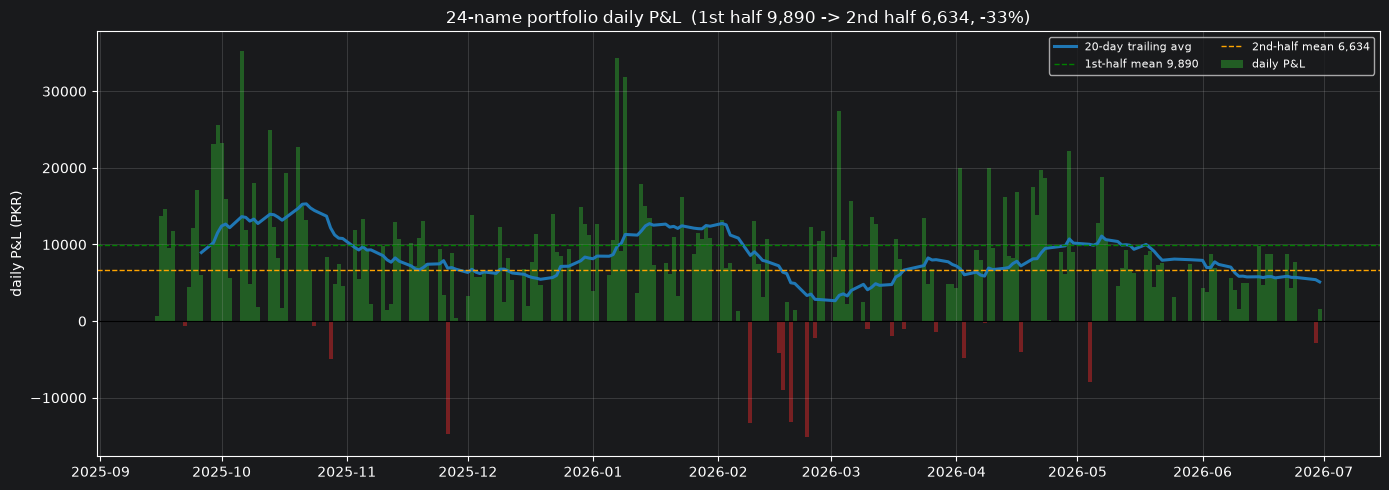

In [7]:
# ---- portfolio daily P&L + 20-day trailing, with first/second-half split ----
# sum P&L across the 24 names per day
port_daily = mid.groupby('date')['pnl_pkr'].sum().sort_index()
# 20-day trailing average (the trend line)
trail = port_daily.rolling(20, min_periods=10).mean()
# halves
h = len(port_daily)//2
h1, h2 = port_daily.iloc[:h].mean(), port_daily.iloc[h:].mean()

fig, ax = plt.subplots(figsize=(14,5))
ax.bar(port_daily.index, port_daily.values, width=1.0,
       color=np.where(port_daily>0,'#2ca02c','#d62728'), alpha=0.5, label='daily P&L')
ax.plot(trail.index, trail.values, color='#1f77b4', lw=2.2, label='20-day trailing avg')
ax.axhline(h1, color='green', ls='--', lw=1, label=f'1st-half mean {h1:,.0f}')
ax.axhline(h2, color='orange', ls='--', lw=1, label=f'2nd-half mean {h2:,.0f}')
ax.axhline(0, color='black', lw=0.8)
ax.set_title(f'24-name portfolio daily P&L  (1st half {h1:,.0f} -> 2nd half {h2:,.0f}, '
             f'{100*(h2-h1)/h1:+.0f}%)')
ax.set_ylabel('daily P&L (PKR)'); ax.legend(fontsize=8, ncol=2); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

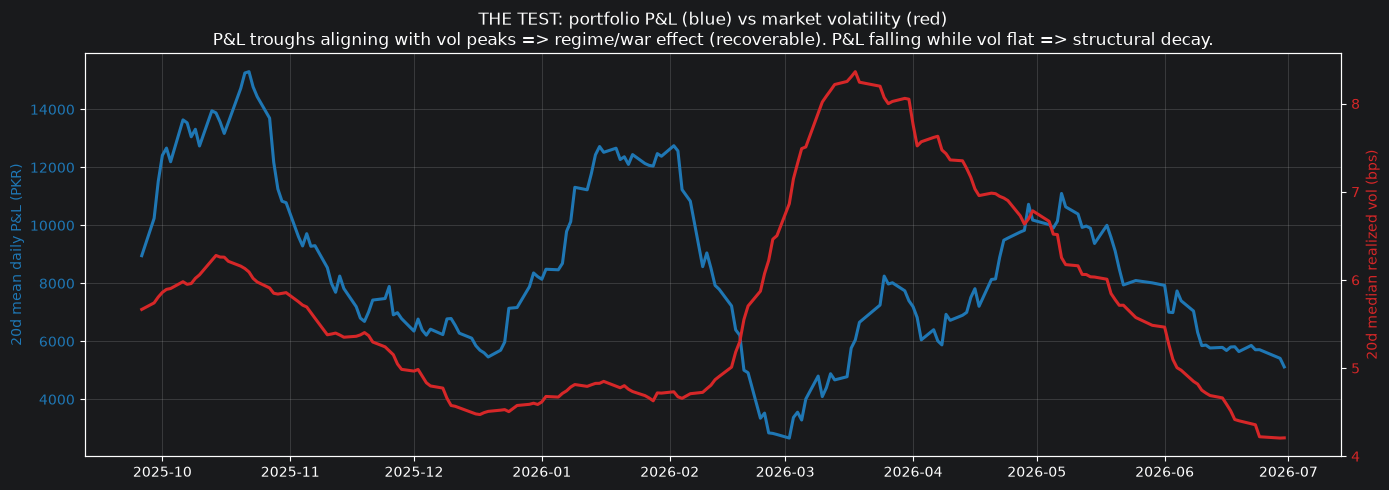

correlation (20d P&L trend vs 20d vol trend): -0.13
strongly negative (< -0.4) supports the vol-regime / war hypothesis:
the edge shrinks precisely when volatility is high, recovers when it falls.


In [8]:
# ---- THE KEY TEST: portfolio P&L vs market-wide realized volatility ----
# pull median realized_vol_bps across the 24 names per day from the feature store
if HAVE_DUCK:
    # one query per name, concatenated -> daily median vol across the portfolio
    frames = []
    for sym in PORT:
        q = f"""SELECT regexp_extract(filename,'date=([0-9-]+)',1) AS d,
                       median(realized_vol_bps) AS rv
                FROM read_parquet('{FS_ROOT}/{sym}/date=*.parquet', filename=true)
                WHERE realized_vol_bps > 0 GROUP BY d"""
        t = duckdb.sql(q).df(); t['symbol'] = sym; frames.append(t)
    allv = pd.concat(frames)
    allv = allv[allv.d != '']
    allv['date'] = pd.to_datetime(allv['d'])
    # market-wide vol = median across names per day (robust to one name spiking)
    mkt_vol = allv.groupby('date')['rv'].median().sort_index()
else:
    # fallback proxy if duckdb unavailable: cross-name P&L dispersion as a vol stand-in
    mkt_vol = mid.groupby('date')['pnl_pkr'].std().sort_index()
    print('duckdb unavailable -- using cross-name P&L dispersion as a vol proxy')

# align the two series on common dates
common = port_daily.index.intersection(mkt_vol.index)
pnl_t = port_daily.reindex(common).rolling(20, min_periods=10).mean()
vol_t = mkt_vol.reindex(common).rolling(20, min_periods=10).mean()

# dual-axis: P&L trend (left) vs market vol trend (right)
fig, ax = plt.subplots(figsize=(14,5))
ax.plot(pnl_t.index, pnl_t.values, color='#1f77b4', lw=2.2, label='20d portfolio P&L (left)')
ax.set_ylabel('20d mean daily P&L (PKR)', color='#1f77b4')
ax.tick_params(axis='y', labelcolor='#1f77b4')
ax2 = ax.twinx()
ax2.plot(vol_t.index, vol_t.values, color='#d62728', lw=2.2, label='20d market vol (right)')
ax2.set_ylabel('20d median realized vol (bps)', color='#d62728')
ax2.tick_params(axis='y', labelcolor='#d62728')
ax.set_title('THE TEST: portfolio P&L (blue) vs market volatility (red)\n'
             'P&L troughs aligning with vol peaks => regime/war effect (recoverable). '
             'P&L falling while vol flat => structural decay.')
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# quantify: correlation of P&L and vol (trailing series). Negative = vol hurts P&L.
c = pd.concat([pnl_t, vol_t], axis=1).dropna()
c.columns = ['pnl','vol']
corr = c['pnl'].corr(c['vol'])
print(f'correlation (20d P&L trend vs 20d vol trend): {corr:+.2f}')
print('strongly negative (< -0.4) supports the vol-regime / war hypothesis:')
print('the edge shrinks precisely when volatility is high, recovers when it falls.')

In [9]:
# ---- regime vs decay: is the erosion BROAD (all names) or CONCENTRATED (few)? ----
# per-name first-half vs second-half mean daily P&L
recs = []
for sym in PORT:
    s = mid[mid.symbol==sym].sort_values('date')['pnl_pkr']
    hh = len(s)//2
    a, b = s.iloc[:hh].mean(), s.iloc[hh:].mean()
    recs.append({'symbol': sym, 'h1': a, 'h2': b, 'change': b-a,
                 'change_pct': 100*(b-a)/a if a else np.nan})
split = pd.DataFrame(recs).sort_values('change')
# how many names declined? if ~all -> broad (regime). if a few -> concentrated (decay).
n_down = (split['change']<0).sum()
print(f'{n_down} of {len(PORT)} names declined 1st->2nd half.')
print('BROAD decline (most names down) => regime effect (supports war/vol).')
print('CONCENTRATED (a few names crater, rest flat) => structural decay.\n')
split.style.format({'h1':'{:,.0f}','h2':'{:,.0f}','change':'{:+,.0f}','change_pct':'{:+.0f}%'})

15 of 24 names declined 1st->2nd half.
BROAD decline (most names down) => regime effect (supports war/vol).
CONCENTRATED (a few names crater, rest flat) => structural decay.



,symbol,h1,h2,change,change_pct
12,NBP,"1,144",-741,"-1,885",-165%
14,NRL,427,4,-423,-99%
2,DGKC,240,-22,-262,-109%
19,PSO,639,379,-260,-41%
4,FFC,448,204,-244,-54%
6,HUBC,313,161,-152,-49%
11,MLCF,566,417,-149,-26%
1,BAFL,331,206,-125,-38%
8,LUCK,622,497,-125,-20%
18,PPL,566,452,-114,-20%


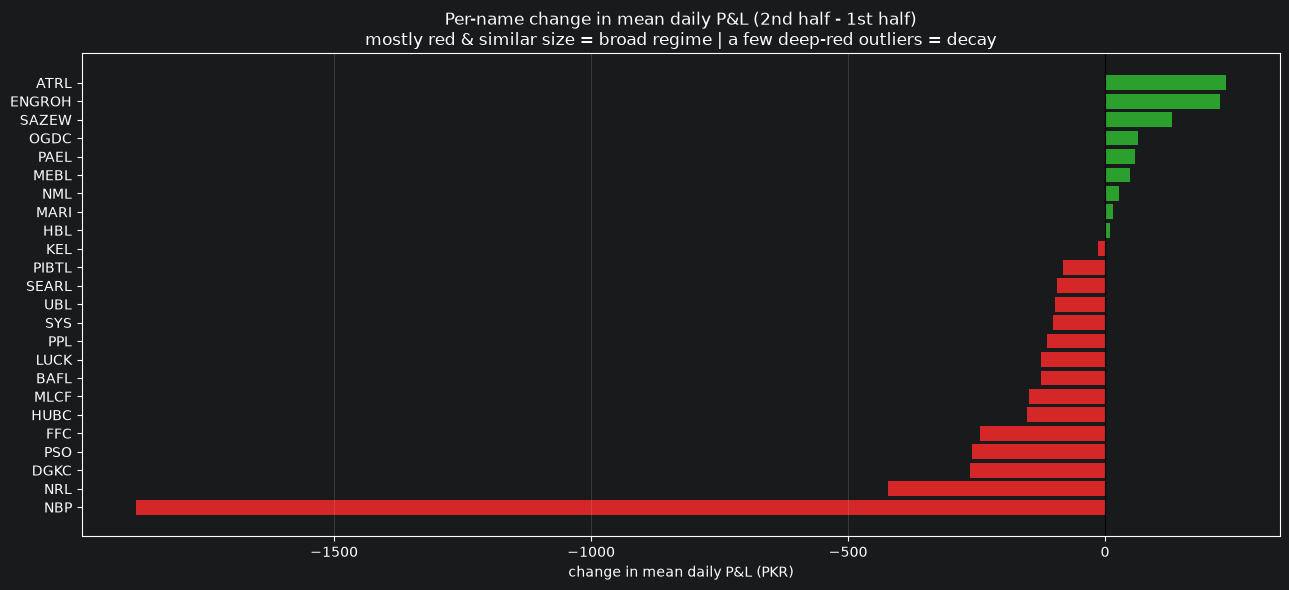

In [10]:
# ---- per-name change bar chart: the visual regime-vs-decay read ----
fig, ax = plt.subplots(figsize=(13,6))
colors = np.where(split['change']>0, '#2ca02c', '#d62728')
ax.barh(split['symbol'], split['change'], color=colors)
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Per-name change in mean daily P&L (2nd half - 1st half)\n'
             'mostly red & similar size = broad regime | a few deep-red outliers = decay')
ax.set_xlabel('change in mean daily P&L (PKR)')
ax.grid(alpha=0.3, axis='x')
plt.tight_layout(); plt.show()

### Verdict logic

- **Strong negative P&L-vs-vol correlation (chart 2) + broad decline (most names down, chart 4)** → the erosion is a **volatility regime** (consistent with the war news-cycle driving jumps). This is **recoverable**: size the book for the good names, expect the run-rate to recover as vol normalises, and consider a vol-gate that pulls quotes on high-jump days.
- **Flat P&L-vs-vol correlation + concentrated decline (a few names crater)** → **structural decay** in specific names. Drop the decaying names; don't wait for recovery.

*The notebook shows which. The war attribution itself is your call from the news calendar overlaid on chart 2's vol peaks.*